In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CrimeAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .getOrCreate()


In [2]:
import os

csv_path = r"D:\Crime\Crimes.csv"   # <-- your updated path

if not os.path.exists(csv_path):
    raise FileNotFoundError("CSV path incorrect. Fix and rerun.")

df = spark.read.csv(csv_path, header=True, inferSchema=True)

print("Total Rows:", df.count())
df.printSchema()
df.show(5)


Total Rows: 7842937
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)

+--------+-----------+--------------------+--------------------+----+-------

In [3]:
important_cols = [
    "Primary Type", "Description", "Location Description",
    "Arrest", "Domestic", "District", "Community Area",
    "Year", "Latitude", "Longitude"
]

df2 = df.select(important_cols)
df2.show(5)


+------------------+--------------------+--------------------+------+--------+--------+--------------+----+--------+---------+
|      Primary Type|         Description|Location Description|Arrest|Domestic|District|Community Area|Year|Latitude|Longitude|
+------------------+--------------------+--------------------+------+--------+--------+--------------+----+--------+---------+
|             THEFT|           OVER $500|           RESIDENCE| false|    true|       6|            44|2018|    NULL|     NULL|
|DECEPTIVE PRACTICE|FINANCIAL IDENTIT...|                NULL| false|   false|       8|            63|2016|    NULL|     NULL|
|         NARCOTICS| POSS: HEROIN(WHITE)|              STREET|  true|   false|       2|            41|2018|    NULL|     NULL|
|   CRIMINAL DAMAGE|          TO VEHICLE|              STREET| false|   false|      25|            19|2018|    NULL|     NULL|
|DECEPTIVE PRACTICE|FINANCIAL IDENTIT...|               OTHER| false|   false|       8|            56|2015|    

In [4]:
df3 = df2.dropDuplicates()
df3 = df3.dropna(subset=["Primary Type", "Latitude", "Longitude"])

print("After Cleaning:", df3.count())
df3.show(5)


After Cleaning: 6942689
+-------------------+--------------------+--------------------+------+--------+--------+--------------+----+------------+-------------+
|       Primary Type|         Description|Location Description|Arrest|Domestic|District|Community Area|Year|    Latitude|    Longitude|
+-------------------+--------------------+--------------------+------+--------+--------+--------------+----+------------+-------------+
|           BURGLARY|      UNLAWFUL ENTRY|    RESIDENCE-GARAGE| false|   false|       8|            65|2015|41.784983382|-87.731495823|
|              THEFT|      $500 AND UNDER|       PARK PROPERTY| false|   false|       2|            37|2015|41.795991039|-87.630542489|
|          NARCOTICS|POSS: CANNABIS 30...|            SIDEWALK|  true|   false|      15|            25|2015|41.879485593|-87.746432819|
|MOTOR VEHICLE THEFT|          AUTOMOBILE|              STREET|  true|   false|      12|            31|2015| 41.85765368|-87.676732923|
|      OTHER OFFENSE|HAR

In [5]:
from pyspark.sql.functions import count, col

crime_freq = df3.groupBy("Primary Type") \
                .agg(count("*").alias("count")) \
                .orderBy(col("count").desc())

crime_freq.show(10)


+-------------------+-------+
|       Primary Type|  count|
+-------------------+-------+
|              THEFT|1332022|
|            BATTERY|1297830|
|    CRIMINAL DAMAGE| 832405|
|          NARCOTICS| 637651|
|            ASSAULT| 481196|
|      OTHER OFFENSE| 455998|
|           BURGLARY| 402731|
|MOTOR VEHICLE THEFT| 361477|
| DECEPTIVE PRACTICE| 295952|
|            ROBBERY| 286608|
+-------------------+-------+
only showing top 10 rows


In [6]:
crime_pdf = crime_freq.limit(30).toPandas()
crime_pdf


,Primary Type,count
0,THEFT,1332022
1,BATTERY,1297830
2,CRIMINAL DAMAGE,832405
3,NARCOTICS,637651
4,ASSAULT,481196
5,OTHER OFFENSE,455998
6,BURGLARY,402731
7,MOTOR VEHICLE THEFT,361477
8,DECEPTIVE PRACTICE,295952
9,ROBBERY,286608


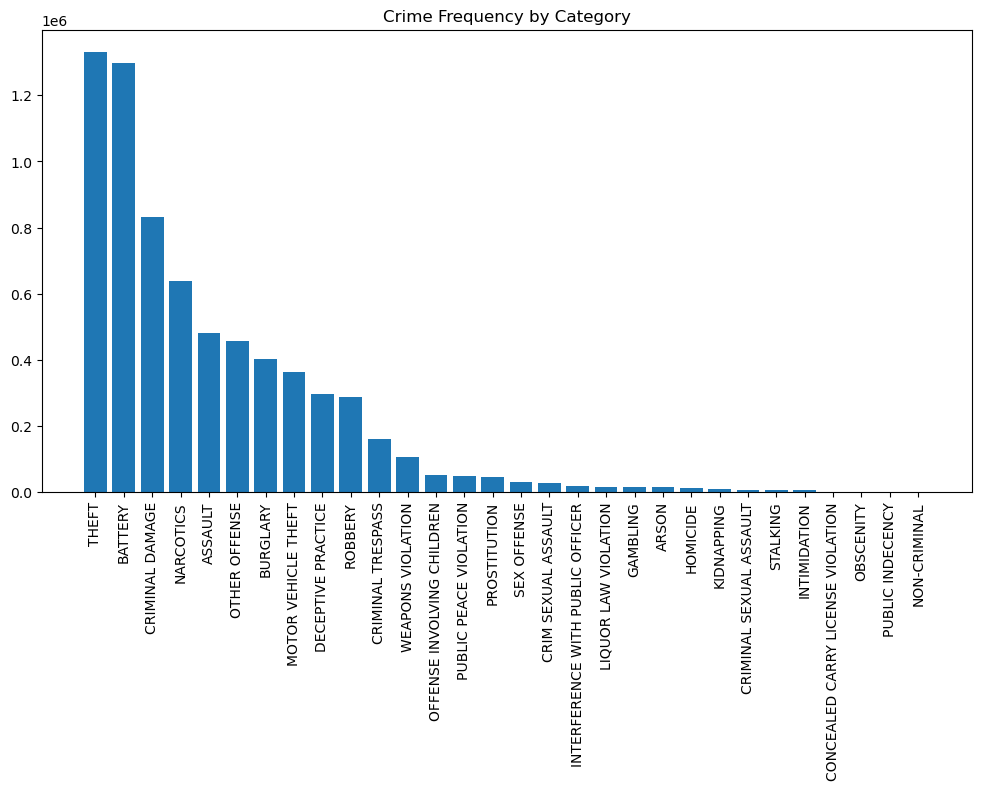

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(crime_pdf["Primary Type"], crime_pdf["count"])
plt.xticks(rotation=90)
plt.title("Crime Frequency by Category")
plt.show()


In [8]:
# STEP 5B — Crime Heatmap (Latitude & Longitude Visualization)

!pip install folium

import folium
from folium.plugins import HeatMap

# Take only lat/lon columns and limit to safe number (Windows-friendly)
heat_df = df3.select("Latitude", "Longitude").dropna().limit(20000)
heat_pd = heat_df.toPandas()

# Initialize map centered around Chicago (modify if needed)
crime_map = folium.Map(location=[41.85, -87.65], zoom_start=10)

# Convert to list of points
heat_data = heat_pd[["Latitude", "Longitude"]].values.tolist()

HeatMap(heat_data, radius=8).add_to(crime_map)

crime_map


In [9]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Latitude", "Longitude", "Year"],
    outputCol="features"
)

df_features = assembler.transform(df3)

df_features.select("Latitude", "Longitude", "Year", "features").show(5)


+------------+-------------+----+--------------------+
|    Latitude|    Longitude|Year|            features|
+------------+-------------+----+--------------------+
|41.784983382|-87.731495823|2015|[41.784983382,-87...|
|41.795991039|-87.630542489|2015|[41.795991039,-87...|
|41.879485593|-87.746432819|2015|[41.879485593,-87...|
| 41.85765368|-87.676732923|2015|[41.85765368,-87....|
|41.944391052|-87.660199595|2015|[41.944391052,-87...|
+------------+-------------+----+--------------------+
only showing top 5 rows


In [10]:
numeric_df = df3.select("Latitude", "Longitude", "Year") \
                .dropna() \
                .limit(20000)    # LIMIT prevents RAM crash

pdf = numeric_df.toPandas()

pdf.head()


,Latitude,Longitude,Year
0,41.784983,-87.731496,2015
1,41.795991,-87.630542,2015
2,41.879486,-87.746433,2015
3,41.857654,-87.676733,2015
4,41.944391,-87.660200,2015


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42)
pdf["cluster"] = kmeans.fit_predict(pdf[["Latitude", "Longitude", "Year"]])


In [11]:
pdf.head()


,Latitude,Longitude,Year
0,41.784983,-87.731496,2015
1,41.795991,-87.630542,2015
2,41.879486,-87.746433,2015
3,41.857654,-87.676733,2015
4,41.944391,-87.660200,2015


In [12]:
import folium
from folium.plugins import HeatMap

# Convert Spark DataFrame → Pandas (only Latitude & Longitude)
heat_df = df3.select("Latitude", "Longitude").limit(20000).toPandas()

# Base map centered on Chicago
crime_map = folium.Map(location=[41.85, -87.65], zoom_start=11)

# Add heatmap layer
HeatMap(heat_df).add_to(crime_map)

crime_map


In [13]:
output_path = r"D:\Crime\clustered_data_windows.csv"
pdf.to_csv(output_path, index=False)

print("Saved:", output_path)


Saved: D:\Crime\clustered_data_windows.csv
